In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker
from pprint import pprint

import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

plot_dir = './plots'
latex = True

In [2]:
config1 = dict(
    # input_filename = 'hessian120k16k_eigs.npz',
    input_filename = 'hessian_pb_eigs.npz',  # half powers of 2
    deg_m = 3,
    effective_n = 80_000,
    xlim = (-150, 150),
    ylim = [(0, 0.15), (0, 0.15), (0, 0.15)],
    nbins = (80, 200),
    label_mode = 'pow-dec',
    save_filename = 'hessian_pb',
)

# -------

# config = config1
# config = config2
config = config1

Idx   Size   Repeat
---  -----   ------
0     1024       16
1     2048        8
2     4096        4
3     8192        2
4    16384        1
5    32768        1

proc name: AMD Ryzen 7 5800X 8-Core Processor
num proc:  16
date:      2026-04-23 19:35:55 AEST



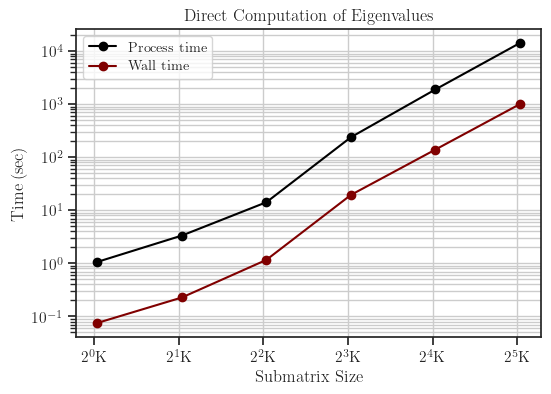

In [3]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
repeats = out['repeats']             # Repeats of sampling
eigs_repeated = out['eigs']          # List of eigenvalues per each submatrix
eigs = out['eigs']                   # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)
proc_name = out['proc_name']
num_proc = out['num_proc']
date = out['date']

# concatenate all repeats
max_repeat = 8
eigs = [None] * len(eigs_repeated)
for i in range(len(eigs_repeated)):
    rep_size = min(eigs_repeated[i].shape[0], max_repeat)
    eigs[i] = eigs_repeated[i][:rep_size, :].ravel()

# Sizes of submatrices
print('Idx   Size   Repeat')
print('---  -----   ------')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}  {repeats[i]:>7d}')
print('')
print(f'proc name: {proc_name}')
print(f'num proc:  {num_proc}')
print(f'date:      {date}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

Plot saved to "/home/sia/work/github/freealg/notebooks/hessia_pb_ridge.pdf".


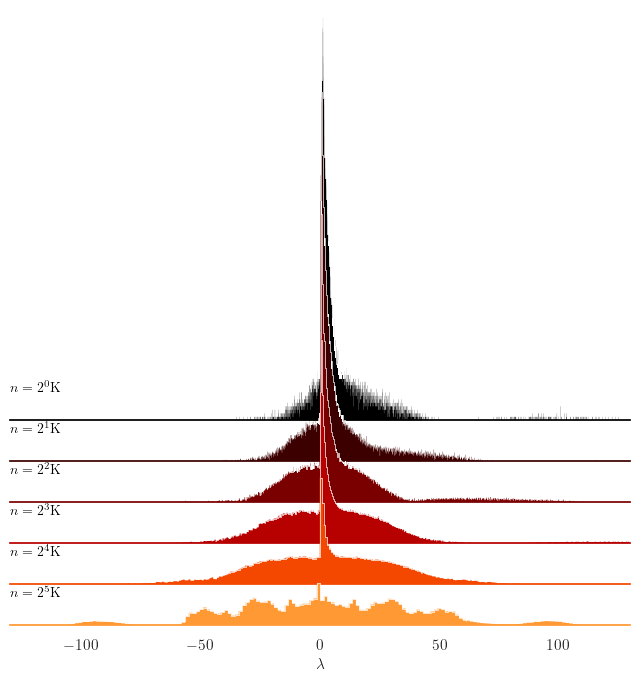

In [4]:
# eigs_no_atom = [None] * len(eigs)
# tol = 1e-4
# for i in range(len(eigs)):
#     eigs_no_atom[i] = eigs[i][numpy.abs(eigs[i]) > tol]

ridgeplot(sizes,
          # eigs=eigs_no_atom,
          eigs=eigs,
          log=False, scaley=False, hspace=-0.9,
          text_side='left', xlim=(-130, 130), ylim=None, figsize=(8, 8),
          label_mode='pow-int',
          # label_mode='pow-dec',
          latex=latex, title='',
          save='hessia_pb_ridge.pdf', nbins=2000)

# Fit Spectral Curves

In [14]:
# Index to choose the initial sub-matrix size
start_idx = 0

# Detect support from histogram
print('\n------------------------------------------')
print('Support (detected from histogram):')
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=False,
                      print_info=True)

# Stieltjes options
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 20,
    anchor_mode = 'asymptote',   # empirical, asymptotic
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 1,
    anchor_ratio = 0.01,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.1,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes options
inv_stieltjes_opt = dict(
    delta = 1e-5,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 1,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'direct',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'uniform',  # 'uniform, small_delta
)

# Estimate the initia ratio "c0" from "c" of the larger matrix
ratio = sizes[start_idx] / config['effective_n']

# Main object
af = AlgebraicForm(eigs[start_idx],
                   ratio=ratio,
                   support=None,
                   # support=support,
                   n=sizes[start_idx],
                   log=False,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# Polynomial degrees
# deg_m = config['deg_m']
# deg_z = 2
deg_m, deg_z = 8, 2

# Moments to be used as constraints in fitting
deg_mu = 2
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

print('\n------------------------------------------')
coeffs = af.fit(
    deg_m, deg_z, reg=0,
    r_min=1.8, r_max=2.2, n_r=5,
    y_scale=1.0, gamma=1.0,
    n_samples=4096,
    cut_eps=0.01,
    normalize=True,
    triangular=None,
    # triangular=(-1, 1),
    mu=mu,
    # mu='auto',
    mu_reg=None, verbose=True, plot=False)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
| bulk 1 | interval: (-35.15220, -31.82882) | center: -33.49051 |  mass:  0.04% |
| bulk 2 | interval: (-30.72103,  47.93234) | center:   8.60566 |  mass: 98.39% |
| bulk 3 | interval: ( 49.04013,  50.14793) | center:  49.59403 |  mass:  0.01% |
| bulk 4 | interval: ( 65.65704,  66.76484) | center:  66.21094 |  mass:  0.01% |
| bulk 5 | interval: ( 72.30381, 103.32203) | center:  87.81292 |  mass:  1.12% |
| bulk 6 | interval: (104.42983, 112.18439) | center: 108.30711 |  mass:  0.27% |
| bulk 7 | interval: (113.29218, 121.04674) | center: 117.16946 |  mass:  0.11% |
| bulk 8 | interval: (122.15453, 125.47791) | center: 123.81622 |  mass:  0.04% |
| bulk 9 | interval: (128.80129, 129.90909) | center: 129.35519 |  mass:  0.01% |
mass(x) ~ 0.2936 + -0.0025 * x

------------------------------------------
fit residual max  : 1.8378e-09
fit residual 99.9%: 1.8373e-09

Coefficients (real)
+0.99964241 +135.28152681

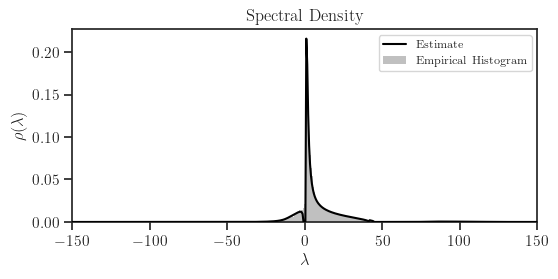

mass: 0.998897


In [15]:
x_min, x_max = config['xlim']
x0 = numpy.linspace(x_min, x_max, 500)
rho0 = af.density(x0, plot=True, latex=latex)

mass = numpy.trapz(rho0, x0)
print('mass: %f' % mass)

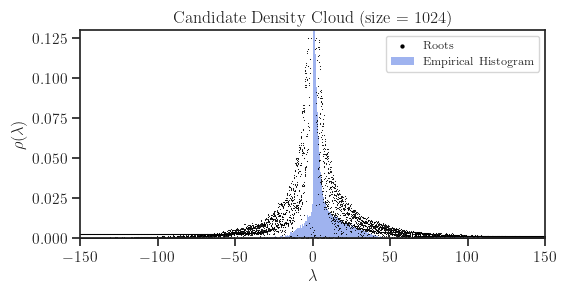

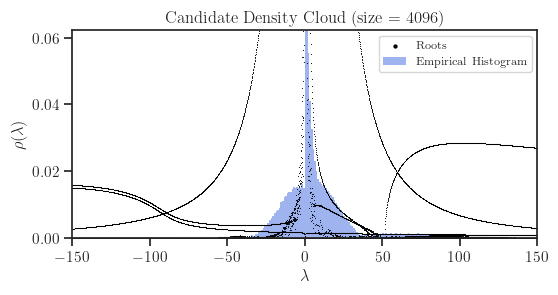

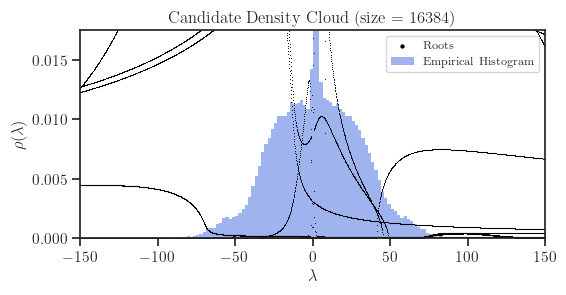

In [16]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min, x_max = config['xlim']
# x_highres = numpy.geomspace(x_min, x_max, 2000)
x_highres = numpy.linspace(x_min, x_max, 2000)

# for idx in [start_idx, start_idx+1, sizes.size-1]:
for idx in range(start_idx, sizes.size, 2):
    # ylim = (0, 0.06) if idx == sizes.size - 1 else None
    e = eigs[idx]
    h = numpy.histogram(e, 100, density=True)[0]
    ylim = (0, 1.1 * float(numpy.max(h[5:])))
    af.candidates(
        size=sizes[idx],
        kind='deformed',
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6,
        ylim=ylim, latex=latex)

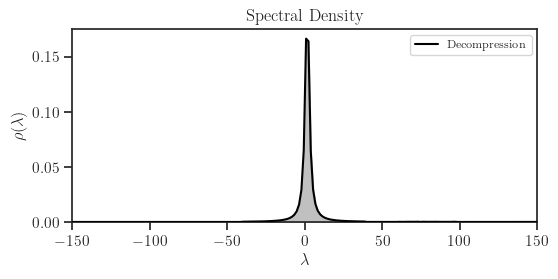

In [37]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
# x_min = 1e-5
# x_max = 1e3
x_min, x_max = config['xlim']
# x = numpy.geomspace(x_min, x_max, 500)
x = numpy.linspace(x_min, x_max, 200)

newton_opt = dict(
    # dt_max=0.001,
    # dt_min=1e-10,
    # tol=1e-8,
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x, atoms = af.decompress(
    fd_sizes, x=x, mode='deform', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

success rate per t: [1. 1. 1. 1. 1. 1.]
success rate per t: [1. 1. 1. 1. 1. 1.]
success rate per t: [1. 1. 1. 1. 1. 1.]
success rate per t: [1. 1. 1. 1. 1. 1.]


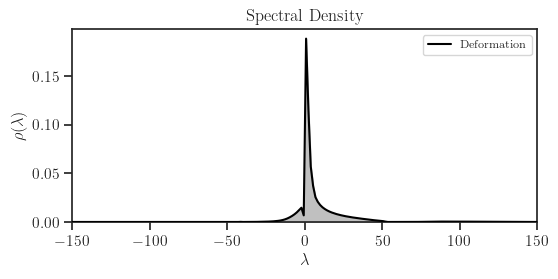

In [55]:
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]
x = numpy.linspace(x_min, x_max, 200)

newton_opt = dict(
    dt_max=0.02,
)

rho, x = af.deform(
    fd_sizes, x=x, method='moc', min_n_times=0,
    newton_opt=newton_opt, return_atoms=False,
    atom_eps=0, verbose=True, plot=True, latex=latex)

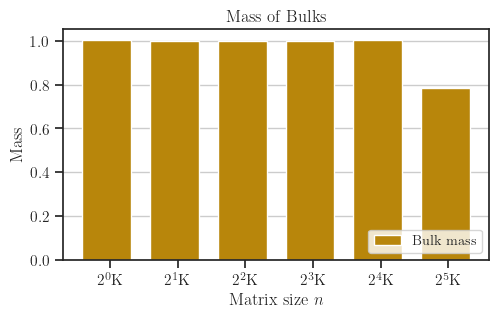

In [13]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, save=False, latex=latex)

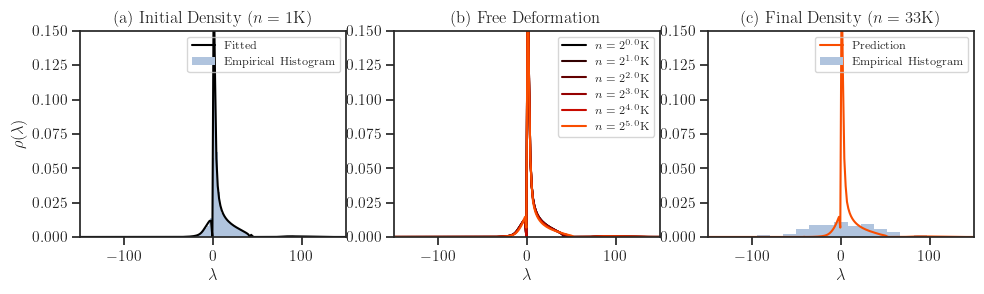

In [56]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], xlim=config['xlim'],
          ylim=config['ylim'], share_ax=False, layout='horizontal', title='Free Deformation',
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          nbins=config['nbins'],
          label_mode=config['label_mode'],
          # save=join(plot_dir, config['save_filename'] + '-flow.pdf'),
          latex=latex)

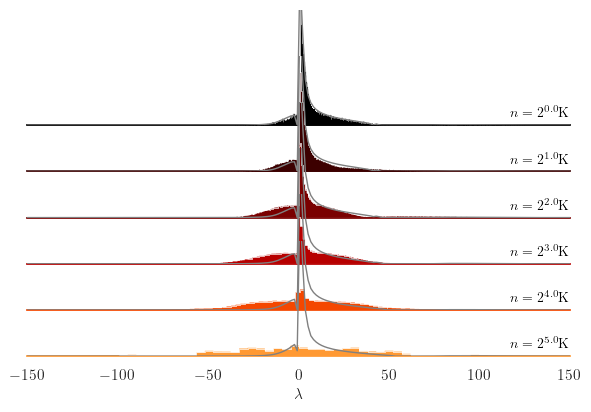

In [57]:
ridgeplot(fd_sizes, x, rho, eigs,
          text_side='right',
          hspace=-0.6, figsize=(7, 4.5),
          scaley=False, ylim_factor=0.75,
          xlim=config['xlim'], rho_color='gray',
          # nbins=120,
          label_mode=config['label_mode'],
          save=False,
          # save=join(plot_dir, config['save_filename'] + '-ridge.pdf'),
          latex=latex)